### Cell 1 — Setup and load StatCan files

Load Canadian retail trade (Table 20-10-0056) and food CPI (Table 18-10-0004) from the statcan subfolder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("../..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# Load both StatCan files
retail = pd.read_csv(DATA_RAW / "statcan" / "statcan_retail_trade_food.csv")
cpi = pd.read_csv(DATA_RAW / "statcan" / "statcan_food_cpi.csv")

print(f"Retail trade: {retail.shape[0]:,} rows, {retail.shape[1]} columns")
print(f"Food CPI:     {cpi.shape[0]:,} rows, {cpi.shape[1]} columns")


Retail trade: 1,776 rows, 17 columns
Food CPI:     448 rows, 15 columns


### Cell 2 — Inspect the retail trade table

See what columns and values are present so we can filter to what we need (Canada total, Unadjusted, food retailers).

In [2]:
print("RETAIL TRADE TABLE")
print("=" * 60)
print(f"Columns: {retail.columns.tolist()}")
print(f"\nGeography values: {retail['GEO'].unique()}")
print(f"\nNAICS values (first 10):")
naics_col = [c for c in retail.columns if "NAICS" in c.upper() or "Classification" in c][0]
print(retail[naics_col].unique()[:10])
print(f"\nAdjustment values: {retail['Adjustments'].unique() if 'Adjustments' in retail.columns else 'N/A'}")
print(f"\nDate range: {retail['REF_DATE'].min()} to {retail['REF_DATE'].max()}")
print(f"\nSample rows:")
retail.head()

RETAIL TRADE TABLE
Columns: ['REF_DATE', 'GEO', 'DGUID', 'North American Industry Classification System (NAICS)', 'Sales', 'Adjustments', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

Geography values: ['Quebec' 'Ontario' 'Alberta' 'British Columbia']

NAICS values (first 10):
['Food and beverage retailers [445]'
 'Grocery and convenience retailers [4451]'
 'Supermarkets and other grocery retailers (except convenience retailers) [44511]'
 'Specialty food retailers [4452]']

Adjustment values: ['Unadjusted']

Date range: 2017-01 to 2026-03

Sample rows:


,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),Sales,Adjustments,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Quebec,2021A000224,Food and beverage retailers [445],Total retail sales,Unadjusted,Dollars,81,thousands,3,v1446859675,6.9.1.1,2093418.0,NaN,NaN,NaN,0
1,2017-02,Quebec,2021A000224,Food and beverage retailers [445],Total retail sales,Unadjusted,Dollars,81,thousands,3,v1446859675,6.9.1.1,2007762.0,NaN,NaN,NaN,0
2,2017-03,Quebec,2021A000224,Food and beverage retailers [445],Total retail sales,Unadjusted,Dollars,81,thousands,3,v1446859675,6.9.1.1,2225315.0,NaN,NaN,NaN,0
3,2017-04,Quebec,2021A000224,Food and beverage retailers [445],Total retail sales,Unadjusted,Dollars,81,thousands,3,v1446859675,6.9.1.1,2262394.0,NaN,NaN,NaN,0
4,2017-05,Quebec,2021A000224,Food and beverage retailers [445],Total retail sales,Unadjusted,Dollars,81,thousands,3,v1446859675,6.9.1.1,2407747.0,NaN,NaN,NaN,0


### Cell 3 — Inspect the food CPI table

Same exploratory pass for the CPI file. We need to know what product groups are available.

In [3]:
print("FOOD CPI TABLE")
print("=" * 60)
print(f"Columns: {cpi.columns.tolist()}")
print(f"\nGeography values: {cpi['GEO'].unique() if 'GEO' in cpi.columns else 'N/A'}")
print(f"\nProduct groups:")
prod_col = [c for c in cpi.columns if "product" in c.lower() or "Products" in c]
if prod_col:
    print(cpi[prod_col[0]].unique())
print(f"\nDate range: {cpi['REF_DATE'].min()} to {cpi['REF_DATE'].max()}")
print(f"\nSample rows:")
cpi.head()

FOOD CPI TABLE
Columns: ['REF_DATE', 'GEO', 'DGUID', 'Products and product groups', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']

Geography values: ['Canada']

Product groups:
['Food' 'Food purchased from stores' 'Meat' 'Dairy products and eggs'
 'Bakery products' 'Fresh fruit' 'Fresh vegetables']

Date range: 2021-01 to 2026-04

Sample rows:


,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-01,Canada,2016A000011124,Food,2002=100,17,units,0,v41690974,2.3,155.0,NaN,NaN,NaN,1
1,2021-02,Canada,2016A000011124,Food,2002=100,17,units,0,v41690974,2.3,155.6,NaN,NaN,NaN,1
2,2021-03,Canada,2016A000011124,Food,2002=100,17,units,0,v41690974,2.3,155.5,NaN,NaN,NaN,1
3,2021-04,Canada,2016A000011124,Food,2002=100,17,units,0,v41690974,2.3,155.4,NaN,NaN,NaN,1
4,2021-05,Canada,2016A000011124,Food,2002=100,17,units,0,v41690974,2.3,156.6,NaN,NaN,NaN,1


### Cell 4 — Filter retail trade to food-and-beverage level and clean

Keep only NAICS 445 (Food and beverage retailers) — the top-level food retail aggregate. Parse REF_DATE into proper datetime and add a Canada-total row by summing provinces.


In [4]:
naics_col = "North American Industry Classification System (NAICS)"

# Filter to the top-level food retail aggregate
retail_food = retail[retail[naics_col] == "Food and beverage retailers [445]"].copy()

# Parse date
retail_food["DATE"] = pd.to_datetime(retail_food["REF_DATE"], format="%Y-%m")
retail_food["YEAR"] = retail_food["DATE"].dt.year
retail_food["MONTH"] = retail_food["DATE"].dt.month

# Keep useful columns only
retail_food = retail_food[["DATE", "YEAR", "MONTH", "GEO", "VALUE"]].copy()
retail_food = retail_food.rename(columns={"VALUE": "SALES_THOUSANDS_CAD"})

# Build Canada total by summing provinces
canada_total = (
    retail_food.groupby(["DATE", "YEAR", "MONTH"])["SALES_THOUSANDS_CAD"]
    .sum()
    .reset_index()
)
canada_total["GEO"] = "Canada (4 provinces)"

retail_food_all = pd.concat([retail_food, canada_total], ignore_index=True)

print(f"Retail trade rows after filter: {len(retail_food_all):,}")
print(f"Geographies: {retail_food_all['GEO'].unique()}")
print(f"Date range: {retail_food_all['DATE'].min().date()} to {retail_food_all['DATE'].max().date()}")
print(f"\nSample:")
retail_food_all.head()


Retail trade rows after filter: 555
Geographies: ['Quebec' 'Ontario' 'Alberta' 'British Columbia' 'Canada (4 provinces)']
Date range: 2017-01-01 to 2026-03-01

Sample:


,DATE,YEAR,MONTH,GEO,SALES_THOUSANDS_CAD
0,2017-01-01,2017,1,Quebec,2093418.0
1,2017-02-01,2017,2,Quebec,2007762.0
2,2017-03-01,2017,3,Quebec,2225315.0
3,2017-04-01,2017,4,Quebec,2262394.0
4,2017-05-01,2017,5,Quebec,2407747.0


### Cell 5 — Compute monthly seasonality index

For each month, compute the ratio of that month's sales to the annual average. A value of 1.10 means that month is 10% above the yearly average. This is the seasonal pattern our forecasting model should reproduce for Canadian data.


In [5]:
# Compute seasonality for Canada total
canada = retail_food_all[retail_food_all["GEO"] == "Canada (4 provinces)"].copy()

def seasonality_per_year(group):
    annual_avg = group["SALES_THOUSANDS_CAD"].mean()
    group["SEASONAL_INDEX"] = group["SALES_THOUSANDS_CAD"] / annual_avg
    return group

canada_full_years = canada[canada["YEAR"].between(2017, 2025)].copy()
canada_full_years = canada_full_years.groupby("YEAR", group_keys=False).apply(seasonality_per_year)

monthly_seasonality = (
    canada_full_years.groupby("MONTH")["SEASONAL_INDEX"]
    .agg(["mean", "std"])
    .reset_index()
)
monthly_seasonality.columns = ["MONTH", "SEASONAL_INDEX_MEAN", "SEASONAL_INDEX_STD"]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_seasonality["MONTH_NAME"] = [month_names[i-1] for i in monthly_seasonality["MONTH"]]

print("Canadian food retail monthly seasonality (2017–2025 average):")
print(monthly_seasonality[["MONTH_NAME", "SEASONAL_INDEX_MEAN", "SEASONAL_INDEX_STD"]].to_string(index=False))
print(f"\nMonths above average (index > 1.00): {(monthly_seasonality['SEASONAL_INDEX_MEAN'] > 1.0).sum()}")
print(f"Months below average (index < 1.00): {(monthly_seasonality['SEASONAL_INDEX_MEAN'] < 1.0).sum()}")


Canadian food retail monthly seasonality (2017–2025 average):
MONTH_NAME  SEASONAL_INDEX_MEAN  SEASONAL_INDEX_STD
       Jan             0.903527            0.039238
       Feb             0.863011            0.019289
       Mar             0.978423            0.028334
       Apr             0.957322            0.024698
       May             1.039350            0.013819
       Jun             1.041770            0.022479
       Jul             1.053880            0.014759
       Aug             1.040593            0.028634
       Sep             0.992290            0.023938
       Oct             1.005741            0.019356
       Nov             0.985828            0.016267
       Dec             1.138264            0.021395

Months above average (index > 1.00): 6
Months below average (index < 1.00): 6


### Cell 6 — Plot monthly seasonality

Bar chart of the monthly seasonal index. Visual confirmation of which months are peaks (December holidays) and troughs (typically February).


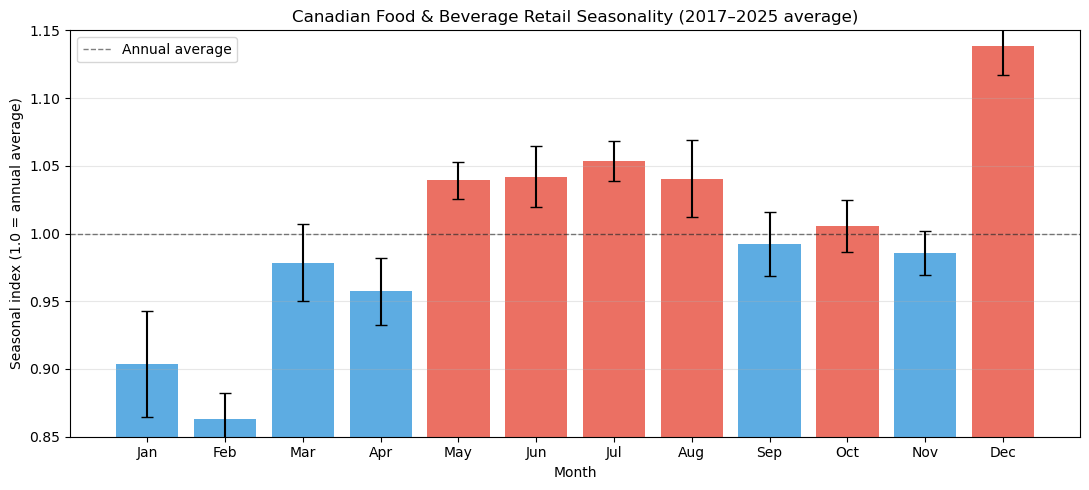

Saved plot to reports/figures/canada_food_seasonality.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    monthly_seasonality["MONTH_NAME"],
    monthly_seasonality["SEASONAL_INDEX_MEAN"],
    yerr=monthly_seasonality["SEASONAL_INDEX_STD"],
    capsize=4,
    color=["#3498db" if v < 1 else "#e74c3c" for v in monthly_seasonality["SEASONAL_INDEX_MEAN"]],
    alpha=0.8,
)
ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Annual average")
ax.set_ylabel("Seasonal index (1.0 = annual average)")
ax.set_xlabel("Month")
ax.set_title("Canadian Food & Beverage Retail Seasonality (2017–2025 average)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0.85, 1.15)
plt.tight_layout()
plt.savefig(FIGURES / "canada_food_seasonality.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved plot to reports/figures/canada_food_seasonality.png")


### Cell 7 — Filter food CPI to perishable categories

Keep only the product groups that map to our dunnhumby perishable categories: Meat, Dairy products and eggs, Bakery products, Fresh fruit, Fresh vegetables.


In [7]:
prod_col = "Products and product groups"

CPI_TO_FRESHFLOW_CATEGORY = {
    "Meat": "MEAT",
    "Dairy products and eggs": "DAIRY",
    "Bakery products": "BAKERY",
    "Fresh fruit": "PRODUCE",
    "Fresh vegetables": "PRODUCE",
}

cpi_filtered = cpi[cpi[prod_col].isin(CPI_TO_FRESHFLOW_CATEGORY.keys())].copy()
cpi_filtered["DATE"] = pd.to_datetime(cpi_filtered["REF_DATE"], format="%Y-%m")
cpi_filtered["FRESHFLOW_CATEGORY"] = cpi_filtered[prod_col].map(CPI_TO_FRESHFLOW_CATEGORY)
cpi_filtered = cpi_filtered[["DATE", prod_col, "FRESHFLOW_CATEGORY", "VALUE"]].copy()
cpi_filtered = cpi_filtered.rename(columns={"VALUE": "CPI_INDEX", prod_col: "STATCAN_GROUP"})

print(f"CPI rows after filter: {len(cpi_filtered):,}")
print(f"\nCategory coverage:")
print(cpi_filtered["FRESHFLOW_CATEGORY"].value_counts().to_string())
print(f"\nDate range: {cpi_filtered['DATE'].min().date()} to {cpi_filtered['DATE'].max().date()}")
print(f"\nLatest CPI values per category:")
latest = cpi_filtered.sort_values("DATE").groupby("FRESHFLOW_CATEGORY").tail(1)
print(latest[["DATE", "STATCAN_GROUP", "FRESHFLOW_CATEGORY", "CPI_INDEX"]].to_string(index=False))


CPI rows after filter: 320

Category coverage:
FRESHFLOW_CATEGORY
PRODUCE    128
MEAT        64
DAIRY       64
BAKERY      64

Date range: 2021-01-01 to 2026-04-01

Latest CPI values per category:
      DATE           STATCAN_GROUP FRESHFLOW_CATEGORY  CPI_INDEX
2026-04-01 Dairy products and eggs              DAIRY      178.3
2026-04-01                    Meat               MEAT      235.4
2026-04-01         Bakery products             BAKERY      216.5
2026-04-01        Fresh vegetables            PRODUCE      198.9


### Cell 8 — Save the cleaned StatCan data

Monthly seasonality index, tidied food CPI by perishable category, and provincial retail series. Used downstream for calibration and inflation adjustment.


In [8]:
seasonality_path = DATA_INTERIM / "canada_seasonality.parquet"
monthly_seasonality.to_parquet(seasonality_path, index=False)
print(f"Saved: {seasonality_path}")

cpi_path = DATA_INTERIM / "canada_food_cpi.parquet"
cpi_filtered.to_parquet(cpi_path, index=False)
print(f"Saved: {cpi_path}")

retail_path = DATA_INTERIM / "canada_retail_food.parquet"
retail_food_all.to_parquet(retail_path, index=False)
print(f"Saved: {retail_path}")

print(f"\nStep 2C interim files:")
for f in [seasonality_path, cpi_path, retail_path]:
    print(f"  {f.name} ({f.stat().st_size / 1e3:.1f} KB)")


Saved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/canada_seasonality.parquet
Saved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/canada_food_cpi.parquet
Saved: /Users/patel/Documents/E/Data analytics own Project/Freshflow Forecasting system/data/interim/canada_retail_food.parquet

Step 2C interim files:
  canada_seasonality.parquet (3.3 KB)
  canada_food_cpi.parquet (5.2 KB)
  canada_retail_food.parquet (8.8 KB)
